PRELIMINARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pl = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='P&L', parse_dates=[0])
bl = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='Balance', parse_dates=[0])
cfs = pd.read_excel(r"C:\Users\aser\OneDrive\Рабочий стол\DATASETS\Apple.xlsx", sheet_name='Cash Flow', parse_dates=[0])
pd.set_option('display.float_format', lambda x: '%.2f' % x)

DATA CLEANING

In [2]:
pl.columns = pl.columns.str.lower()
bl['date'] = pd.to_datetime(bl['date'], format = "%Y.%d.%m")
pl['date'] = pl['date'].dt.year
bl['date'] = bl['date'].dt.year
cfs['date'] = cfs['date'].dt.year
cfs = cfs.rename(columns={"operating cash flow": "ocf", " net equity repurchased": "nqr"})
cfs['dividends'] = np.where(cfs['dividends'] == 'None', 0, cfs['dividends'])

Calculating revenue growth and visualising it. 

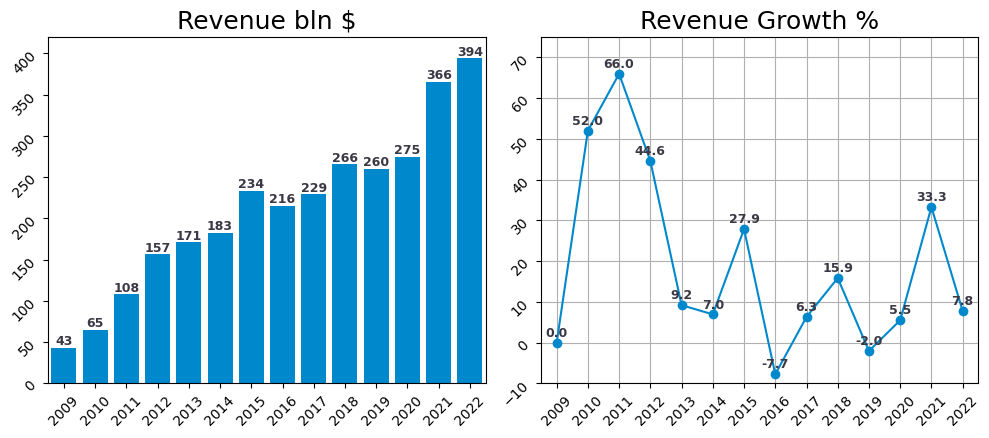

In [3]:
pl['revenue_growth'] = '' #We need empty column for the next command to work 
for i, n in enumerate(pl['revenue']):
    if i < (len(pl['revenue'])-1):
        pl.loc[i,['revenue_growth']] = (pl['revenue'][i]/ pl['revenue'][i+1]-1)*100
    else:
         pl.loc[i,['revenue_growth']] = '0'
pl['revenue_growth'] = round(pl['revenue_growth'].astype('float64'), 2)

revenue_graph, axs = plt.subplots(1,2, figsize = (12,4.5), sharex=True)
axs[0].bar(pl['date'], pl['revenue']/1000, color ='#0088cc')
axs[0].set_title('Revenue bln $', fontsize=18)
axs[1].plot(pl['date'], pl['revenue_growth'], color ='#0088cc', marker='o')
axs[1].set_title('Revenue Growth %', fontsize=18)
axs[1].set_xticks(np.arange(2009, 2023, 1))
axs[0].tick_params(labelsize=10, labelrotation=45)
axs[1].tick_params(labelsize=10, labelrotation=45)
axs[1].grid(True)
axs[0].set_ylim(0,420)
axs[1].set_ylim(-10,75)
axs[1].set_xlim(2008.5, 2022.5)
plt.subplots_adjust(wspace=0.127)
for i in range(len(pl)):
    axs[0].text(pl['date'][i], pl['revenue'][i]/1000, str(round(pl['revenue'][i]/1000)), 
                ha = 'center', va='bottom', fontsize=9, fontweight='semibold', color='#3A3845')
for i in range(len(pl)):
    axs[1].text(pl['date'][i], pl['revenue_growth'][i]+1.5, str(round(pl['revenue_growth'][i], 1)), 
                ha = 'center', fontsize=9, fontweight='semibold', color='#3A3845')



As we can see, Apple's revenue growth is gradually slowing down as the company reaches its critical mass. Let's see what is going on with its margins. 

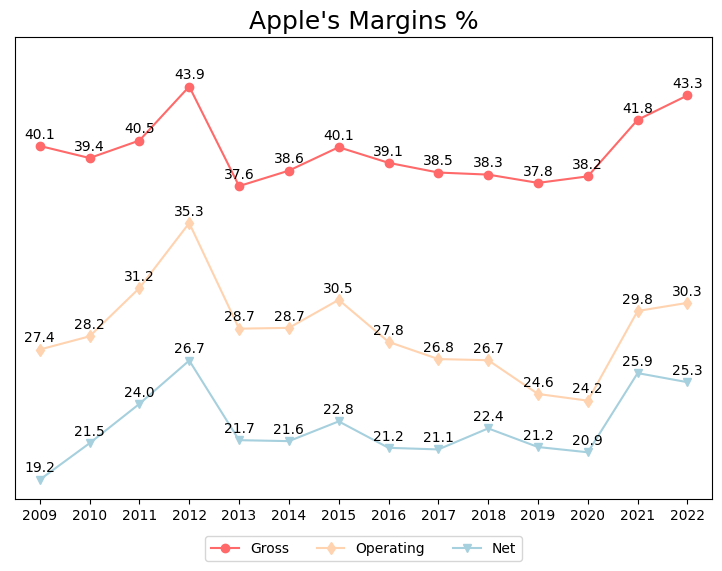

In [4]:
pl['gross_margin'] = round(pl['gross profit'] / pl['revenue'] * 100, 2)
pl['operating_margin'] = round(pl['operating income'] / pl['revenue'] * 100, 2)
pl['net_margin'] = round(pl['net income'] / pl['revenue'] * 100, 2)

margins, axm = plt.subplots(figsize = (9,6))
axm.plot(pl['date'], pl['gross_margin'], color ='#FF6969', label='Gross', marker='o')
axm.plot(pl['date'], pl['operating_margin'], color ='#FFD3B0', label='Operating', marker='d')
axm.plot(pl['date'], pl['net_margin'], color ='#A6D0DD', label='Net', marker='v')
axm.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
axm.set_xticks(np.arange(2009, 2023, 1))
axm.set_title("Apple's Margins %", fontsize=18)
axm.set_ylim(18, 47)
axm.set_xlim(2008.5, 2022.5)
axm.get_yaxis().set_visible(False)
for i in range(len(pl)):
    axm.text(pl['date'][i], pl['gross_margin'][i]+0.5, str(round(pl['gross_margin'][i], 1)),
             ha='center')
for i in range(len(pl)):
    axm.text(pl['date'][i], pl['operating_margin'][i]+0.5, str(round(pl['operating_margin'][i], 1)),
             ha='center')
for i in range(len(pl)):
    axm.text(pl['date'][i], pl['net_margin'][i]+0.5, str(round(pl['net_margin'][i], 1)),
             ha='center')

Gross margin stays at around 40%, slightly fluctuating. However, operating margin is quite volatile, and net income follows its trajectory. To understand why it is happening, we need to analyze operating expenses.

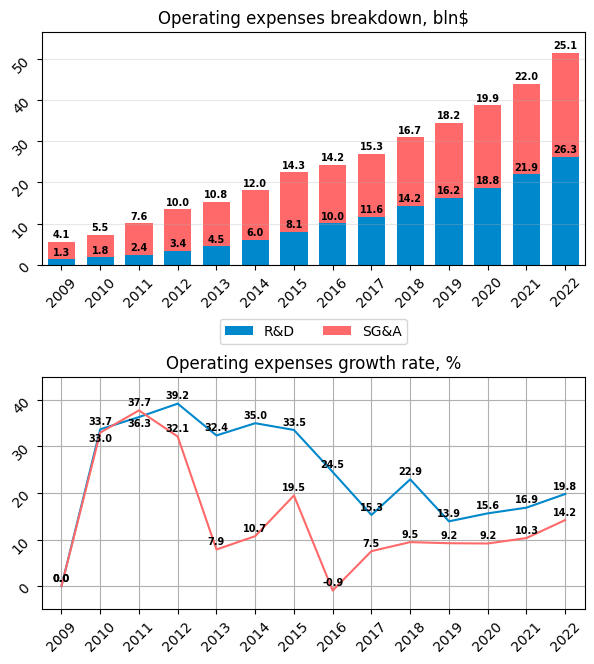

In [5]:

pl['r&d_growth'] = '' #We need empty column for the next command to work 
for i, n in enumerate(pl['r&d']):
    if i < (len(pl['r&d'])-1):
        pl.loc[i,['r&d_growth']] = (pl['r&d'][i]/ pl['r&d'][i+1]-1)*100
    else:
         pl.loc[i,['r&d_growth']] = '0'
pl['r&d_growth'] = round(pl['r&d_growth'].astype('float64'), 2)

pl['sg&a_growth'] = '' #We need empty column for the next command to work 
for i, n in enumerate(pl['sg&a']):
    if i < (len(pl['sg&a'])-1):
        pl.loc[i,['sg&a_growth']] = (pl['sg&a'][i]/ pl['sg&a'][i+1]-1)*100
    else:
         pl.loc[i,['sg&a_growth']] = '0'
pl['sg&a_growth'] = round(pl['sg&a_growth'].astype('float64'), 2)

costs, axd = plt.subplots(2,1, figsize = (7,7.5))
axd[0].bar(pl['date'], pl['r&d']/1000, width=0.7, color ='#0088cc', label='R&D')
axd[0].bar(pl['date'], pl['sg&a']/1000, width=0.7, bottom= pl['r&d']/1000, color ='#FF6969', label='SG&A')
axd[0].set_ylim(0, (pl['sg&a'][0]+pl['r&d'][0])/1000*1.1)
axd[0].legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.37), ncol=2)
axd[0].set_xlim(2008.5, 2022.5)
axd[0].set_xticks(np.arange(2009, 2023, 1))
axd[0].yaxis.grid(True, alpha=0.3)
axd[0].tick_params(labelsize=10, labelrotation=45)
axd[0].set_title('Operating expenses breakdown, bln$')
for i in range(len(pl)):
    axd[0].text(pl['date'][i], pl['r&d'][i]/1000+1, str(round(pl['r&d'][i]/1000, 1)),
                ha='center', fontsize=7, fontweight=600)
for i in range(len(pl)):
    axd[0].text(pl['date'][i], (pl['sg&a'][i]+pl['r&d'][i])/1000+1, str(round(pl['sg&a'][i]/1000, 1)),
                ha='center', fontsize=7, fontweight=600)
plt.subplots_adjust(hspace=0.48)
axd[1].plot(pl['date'], pl['r&d_growth'], color ='#0088cc', label='r&d')
axd[1].plot(pl['date'], pl['sg&a_growth'], color ='#FF6969', label='sg&a')
axd[1].set_xticks(np.arange(2009, 2023, 1))
axd[1].set_xlim(2008.5, 2022.5)
axd[1].set_ylim(-5, 45)
axd[1].tick_params(labelsize=10, labelrotation=45)
axd[1].set_title('Operating expenses growth rate, %')
axd[1].grid(True)
for i in range(len(pl)):
    if pl['date'][i] == 2011:
        axd[1].text(pl['date'][i], pl['r&d_growth'][i]-2, str(round(pl['r&d_growth'][i], 1)),
                ha='center', fontsize=7, fontweight=600)
    else:
        axd[1].text(pl['date'][i], pl['r&d_growth'][i]+1, str(round(pl['r&d_growth'][i], 1)),
                ha='center', fontsize=7, fontweight=600)
        
for i in range(len(pl)):
    if pl['date'][i] == 2010:
        axd[1].text(pl['date'][i], pl['sg&a_growth'][i]-2, str(round(pl['sg&a_growth'][i], 1)),
                ha='center', fontsize=7, fontweight=600)
    else:
        axd[1].text(pl['date'][i], (pl['sg&a_growth'][i])+1, str(round(pl['sg&a_growth'][i], 1)),
                ha='center', fontsize=7, fontweight=600)


Since 2011, the growth rate of R&D expenses has been significantly higher than SG&A's. As a result, its share of operating expenses has increased from 23% to 51% and continues to drag Apple's profitability down. 

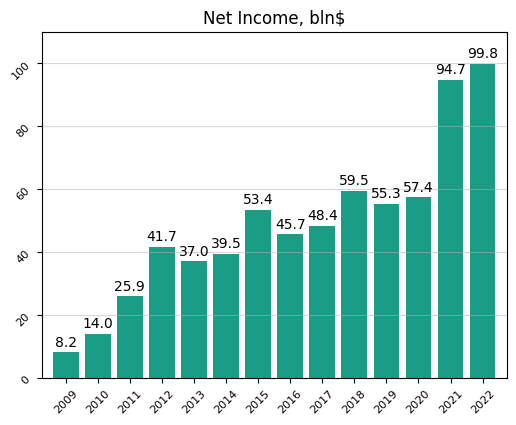

In [97]:
income_graph, inx = plt.subplots(figsize=(6, 4.5))
inx.bar(pl['date'], pl['net income']/1000, color='#1B9C85')
inx.set_xlim(2008.25, 2022.75)
inx.set_ylim(0, 110)
inx.set_xticks(np.arange(2009, 2023,1))
inx.tick_params(labelsize=8, labelrotation=45)
inx.yaxis.grid(True, alpha=0.5)
inx.set_title('Net Income, bln$')
for i in range(len(pl)):
    inx.text(pl['date'][i], pl['net income'][i]/1000+2, str(round(pl['net income'][i]/1000, 1)),
             ha='center')

However, operatins expenses seem to be under control, because Apple's profits continue to rise.

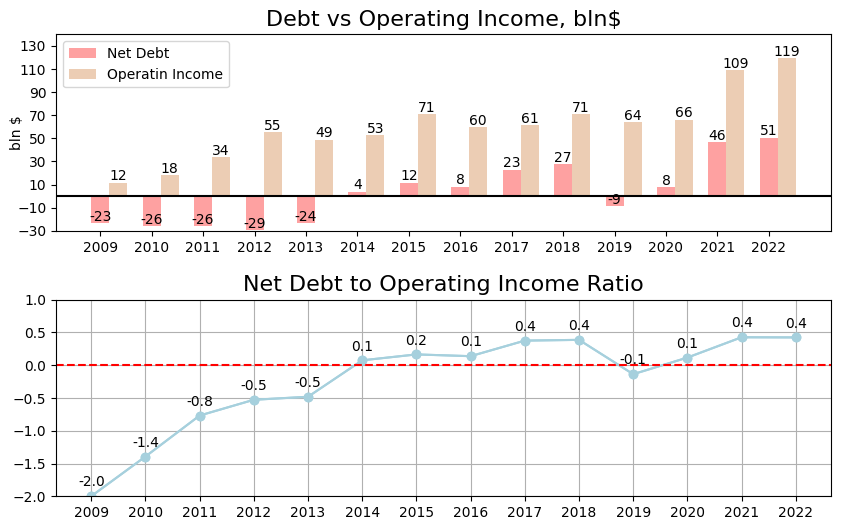

In [73]:
net_debt = bl['long-term debt'] - bl['cash on hand']
nd_op_in = net_debt / pl['operating income']

debt, axf = plt.subplots(2, 1, figsize=(10,6))
axf[0].bar(bl['date'], net_debt/1000, width=0.35, label='Net Debt', color='#FEA1A1')
axf[0].axhline(y=0, color='k', linestyle='-')
axf[0].bar(pl['date'] + 0.35, pl['operating income']/1000, width=0.35, label='Operatin Income', color='#ECCDB4')
axf[0].set_title('Debt vs Operating Income, bln$', fontsize=16)
axf[0].set_ylabel('bln $', labelpad=-5)
axf[0].legend()
axf[0].set_ylim(-30, 140)
axf[0].set_xticks(np.arange(2009, 2023,1))
axf[0].set_yticks(np.arange(-30, 140,20))
for i in range(len(pl)):
    axf[0].text(pl['date'][i]+0.35, pl['operating income'][i]/1000+2, str(round(pl['operating income'][i]/1000)), ha='center')
for i in range(len(pl)):
    axf[0].text(pl['date'][i], net_debt[i]/1000+2, str(round(net_debt[i]/1000)), ha='center')
axf[1].plot(pl['date'], nd_op_in, color = '#A6D0DD', marker='o')    
axf[1].plot(pl['date'], nd_op_in, color = '#A6D0DD', marker='o')
axf[1].grid(True)
axf[1].set_title('Net Debt to Operating Income Ratio', fontsize=16)
axf[1].axhline(y=0, color='r', linestyle='--')
axf[1].set_xticks(np.arange(2009, 2023,1))
axf[1].set_ylim(-2,1)
for i in range(len(pl)):
    axf[1].text(pl['date'][i], nd_op_in[i]+0.15, str(round(nd_op_in[i], 1)), 
                ha='center')
plt.subplots_adjust(hspace=0.35)

Debt is also under control. Net debt to operating income stays close to zero. Let's see what the company does with its earned cash.

100.57


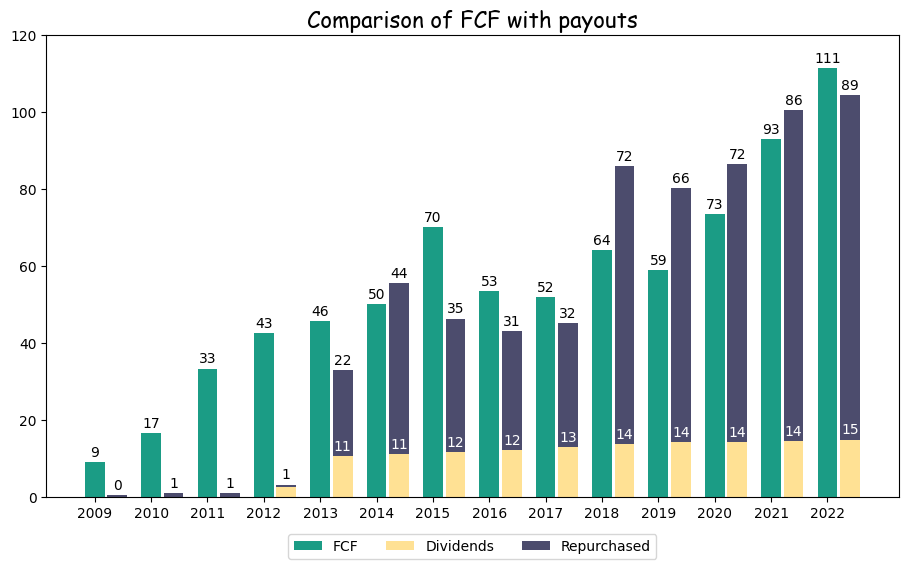

In [96]:
cfs['fcf'] = cfs['ocf'] - cfs['capex']
cfs['payout_ratio'] = (cfs['dividends'] + cfs['nqr']) / cfs['fcf'] * 100

cfs['div + rep'] = cfs['dividends'] + cfs['nqr']
cash_fl, afs = plt.subplots(figsize=(11,6))
afs.bar(cfs['date'], cfs['fcf']/1000, width=0.35, label='FCF', color = '#1B9C85')
afs.bar(cfs['date'] + 0.4, cfs['dividends']/1000, width = 0.35, label = 'Dividends', color = '#FFE194')
afs.bar(cfs['date'] + 0.4, cfs['nqr']/1000, width = 0.35, bottom = cfs['dividends']/1000 ,label = 'Repurchased', color = '#4C4C6D')
afs.set_xticks(np.arange(2009, 2023,1))
afs.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
afs.set_ylim(0, 120)
afs.set_title('Comparison of FCF with payouts', fontsize=16, **{'fontname':'Comic Sans MS'})
for i in range(len(cfs)):
    afs.text(cfs['date'][i], cfs['fcf'][i]/1000+1.5, str(round(cfs['fcf'][i]/1000)), ha='center')
for i in range(len(cfs)):
    afs.text(cfs['date'][i]+0.40, (cfs['dividends'][i]+cfs['nqr'][i])/1000+1.5, str(round(cfs['nqr'][i]/1000)), ha='center')
for i in range(len(cfs)):
    if cfs['date'][i] > 2012:
        afs.text(cfs['date'][i]+0.40, cfs['dividends'][i]/1000+1.5, str(round(cfs['dividends'][i]/1000)), 
             ha='center', color = 'white')


print(round(cfs[cfs['date'] >= 2013]['payout_ratio'].mean(), 2))

Since 2013, Apple has been paying 100% of its free cash flow in the form of dividends and buybacks. 